# Fine-tuning for Instructions

In this notebook we will demonstrate how to fine-tune a local LLM for following instructions. We will go through the following steps:
- Load the original OpenAI GPT2 parameters into our local GPT implementation
- 
This notebook is roughly based on chapter seven of [Build A Larger Language Model (from scratch)](https://sebastianraschka.com/llms-from-scratch/) by Sebastian Raschka and I highly recommend the book.


## 1. Prepare the instructions data

We will download the [Alpaca Instruction]('https://huggingface.co/datasets/tatsu-lab/alpaca') dataset and select a subset to work with.

In [1]:
import json
import os
import requests



In [2]:
url = 'https://raw.githubusercontent.com/tatsu-lab/stanford_alpaca/main/alpaca_data.json'

folder = 'instruction'
os.makedirs(folder, exist_ok=True)

fn = os.path.join(folder, 'alpaca_instruction.json')

if not os.path.isfile(fn):
    response = requests.get(url, stream=True)
    with open(fn, 'wb') as f:
        f.write(response.content)

with open(fn, 'r') as f:
    data_raw = json.load(f)

In [3]:
sizes = [len(str(entry)) for entry in data_raw]

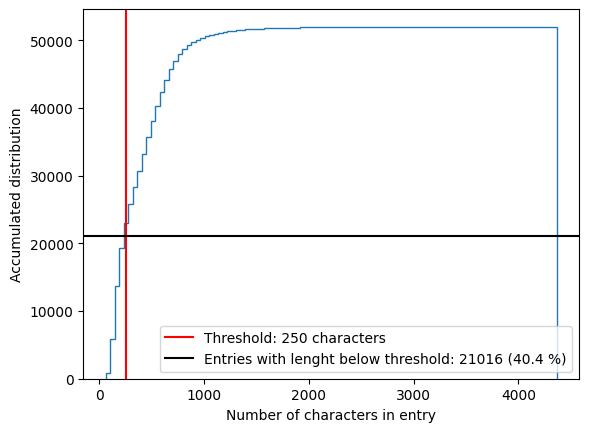

In [4]:
import matplotlib.pylab as plt

threshold = 250

count_below_threshold = len([s for s in sizes if s < threshold])

fig, ax = plt.subplots()

ax.hist(sizes, bins=100, cumulative=True, histtype='step')
ax.axvline(threshold, color='r', label=f'Threshold: {threshold} characters')
ax.axhline(count_below_threshold, color='k', label=f'Entries with lenght below threshold: {count_below_threshold} ({count_below_threshold / len(sizes) * 100:.1f} %)')
ax.set_xlabel('Number of characters in entry')
ax.set_ylabel('Accumulated distribution')
ax.legend()

In [5]:
data_filtered = [e for e in data_raw if len(str(e)) < threshold]

In [6]:
len(data_raw)

52002

In [7]:

len(data_filtered)

21016

In [8]:
N = 1000

import numpy as np

data_sampled = np.random.choice(data_filtered, size=N, replace=False)

In [9]:
len(data_sampled)

1000

In [10]:
data_sampled

array([{'instruction': 'Take the numbers out of the sentence and output the sentence.', 'input': 'AI researchers have made progress in the field in the last 10 years.', 'output': 'AI researchers have made progress in the field in the last years.'},
       {'instruction': 'Classify the following tweet as expressing a positive sentiment, a negative sentiment, or a neutral sentiment.', 'input': 'COVID-19 has changed how we interact with others and how we plan our day-to-day lives.', 'output': 'neutral'},
       {'instruction': 'Create an original haiku related to the theme of rain.', 'input': '', 'output': 'Cool raindrops falling down,\nRefreshing the thirsting ground,\nA quiet blessing.'},
       {'instruction': 'Edit the following sentence such that the tone is more friendly and not intimidating.', 'input': 'We urge you to come to the meeting at 5 pm.', 'output': 'We kindly invite you to come to the meeting at 5 pm.'},
       {'instruction': 'Give me an example of a sentence following t

Next, we will format to Alpaca instruction prompt format:

In [11]:
def format_instruction(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['instruction']}"
    )

    input_text = (
        f"\n\n### Input:\n{entry['input']}" if entry["input"] else ""
    )

    response_text = f"\n\n### Response:\n{entry['output']}"
    return instruction_text + input_text, response_text

Let's split the data into train, validation and test sets:

In [12]:
split_train = int(len(data_sampled) * .85)
split_val = int(len(data_sampled) * 0.95)

data_train = data_sampled[:split_train]
data_val = data_sampled[split_train: split_val]
data_test = data_sampled[split_val:]

print(f'Train size: {len(data_train)}')
print(f'Val size:   {len(data_val)}')
print(f'Test size:  {len(data_test)}')


Train size: 850
Val size:   100
Test size:  50


Now we are ready to implement the PyTorch Dataset class for holding the instruction data:

In [13]:
import torch
from torch.utils.data import Dataset
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.token_lists = []
        for entry in self.data:
            instruction_and_input, response = format_instruction(entry)
            full_text = instruction_and_input + response
            self.token_lists.append(tokenizer.encode(full_text))

    def __getitem__(self, i):
        return self.token_lists[i]
    
    def __len__(self):
        return len(self.token_lists)

dataset_train = InstructionDataset(data_train, tokenizer)
dataset_val = InstructionDataset(data_val, tokenizer)
dataset_test = InstructionDataset(data_test, tokenizer)

In [14]:
tokenizer.decode(dataset_train[6])

'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nList 5 websites for collecting data.\n\n### Response:\n1. Kaggle \n2. Data.World \n3. Google Dataset Search \n4. Open Data Network \n5. Data.gov'

In [15]:
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [16]:
torch.nonzero(torch.tensor([0,3,4,0])).squeeze()

tensor([1, 2])

In [17]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)

def collate(batch, device=device, pad_token_id=50256, ignore_token_id=-100):
    length_max = max([len(item) for item in batch]) + 2

    inputs_list, targets_list = [], []

    for item in batch:
        item_padded = item + [pad_token_id] * (length_max - len(item))

        inputs = torch.tensor(item_padded[:-1])
        targets = torch.tensor(item_padded[1:])

        mask = targets == pad_token_id
        mask_indices = torch.nonzero(mask).squeeze()

        if len(mask_indices) > 1:
            targets[mask_indices[1:]] = ignore_token_id
        
        inputs_list.append(inputs)
        targets_list.append(targets)
    
    inputs_tensor = torch.stack(inputs_list).to(device)
    targets_tensor = torch.stack(targets_list).to(device)

    return inputs_tensor, targets_tensor


batch = [
    [1,2,3],
    [4,5,6,7],
    [8, 9],
]
collate(batch)

mps


(tensor([[    1,     2,     3, 50256, 50256],
         [    4,     5,     6,     7, 50256],
         [    8,     9, 50256, 50256, 50256]], device='mps:0'),
 tensor([[    2,     3, 50256,  -100,  -100],
         [    5,     6,     7, 50256,  -100],
         [    9, 50256,  -100,  -100,  -100]], device='mps:0'))

In [18]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 4 # To save memory

dataloader_train = DataLoader(
    dataset=dataset_train,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
    collate_fn=collate,
)

dataloader_val = DataLoader(
    dataset=dataset_val,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
    collate_fn=collate,
)

dataloader_test = DataLoader(
    dataset=dataset_test,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
    collate_fn=collate,
)

In [19]:
# for i, t in dataloader_train:
#     print(i.shape, t.shape)

Now, let us instantiate our local GPT and load it with open weights from OpenAI:

In [20]:
from sturnus.model import GPTModel

GPT_CONFIG_355_openai = {
    'vocab_size': 50257,
    'block_size': 1024,
    'count_heads': 16,
    'count_blocks': 24,
    'embed_dim': 1024,
    'dropout': 0.1,
    'qkv_bias': True, # Used in GPT2 but typically not in modern LLMs as the biases do not improve performance
}


model = GPTModel(GPT_CONFIG_355_openai)


In [21]:
from sturnus.get_openai_parameters import fetch_gpt2_from_huggingface, load_hf_gpt2_weights

openai_state_dict = fetch_gpt2_from_huggingface(model='gpt2-medium')
load_hf_gpt2_weights(model, openai_state_dict)




/Users/cs/code/sturnus/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 292/292 [00:00<00:00, 9122.94it/s]


In [22]:
model

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_Q): Linear(in_features=1024, out_features=1024, bias=True)
        (W_K): Linear(in_features=1024, out_features=1024, bias=True)
        (W_V): Linear(in_features=1024, out_features=1024, bias=True)
        (out_projection): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln1): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU(approximate='tanh')
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (ln2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_Q): Linear(

In [23]:
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 1024)
  (pos_emb): Embedding(1024, 1024)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_Q): Linear(in_features=1024, out_features=1024, bias=True)
        (W_K): Linear(in_features=1024, out_features=1024, bias=True)
        (W_V): Linear(in_features=1024, out_features=1024, bias=True)
        (out_projection): Linear(in_features=1024, out_features=1024, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ln1): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=1024, out_features=4096, bias=True)
          (1): GELU(approximate='tanh')
          (2): Linear(in_features=4096, out_features=1024, bias=True)
        )
      )
      (ln2): LayerNorm()
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_Q): Linear(

In [24]:
total_parameters = sum([p.numel() for p in model.parameters()])
print(f'Total parameters: {total_parameters}')


Total parameters: 406286336


In [25]:
data_val[0]

{'instruction': 'Categorize this sentence according to its function: She brought me a sweater.',
 'input': '',
 'output': 'This sentence is a statement.'}

In [26]:
input_text, target_text = format_instruction(data_val[10])

print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Construct a regular expression that matches any date in the format of m/d/yyyy.


In [27]:
from sturnus.util import generate, text_to_tokens, tokens_to_text

tokens = generate(
    model=model,
    idx=text_to_tokens(input_text, tokenizer),
    max_new_tokens=35,
    context_size=GPT_CONFIG_355_openai["block_size"],
    eos_id=50256,
)
generated_text = tokens_to_text(tokens, tokenizer)

In [28]:
print(generated_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Construct a regular expression that matches any date in the format of m/d/yyyy.

### Example:

### Example:

### Example:

### Example:

### Example:

### Example:

### Example:


In [29]:
from sturnus.util import calc_loss_loader, calc_loss_loader, train_model_simple


model.to(device)
torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(
        dataloader_train, model, device, batch_count=5
    )
    val_loss = calc_loss_loader(
        dataloader_val, model, device, batch_count=5
)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)  
    
   
   
   

Training loss: 3.9073649883270263
Validation loss: 3.930687761306763


In [30]:
device

device(type='mps')

In [31]:
import time

start_time = time.time()
torch.manual_seed(123)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=0.00005, weight_decay=0.1
)
num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, dataloader_train, dataloader_val, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_instruction(data_val[10])[0],
    tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")  


Ep 1 (Step 000000): Train loss 2.889, Val loss 2.683
Ep 1 (Step 000005): Train loss 1.549, Val loss 1.495
Ep 1 (Step 000010): Train loss 1.414, Val loss 1.469
Ep 1 (Step 000015): Train loss 1.265, Val loss 1.280
Ep 1 (Step 000020): Train loss 1.401, Val loss 1.501
Ep 1 (Step 000025): Train loss 1.259, Val loss 1.310
Ep 1 (Step 000030): Train loss 1.260, Val loss 1.317
Ep 1 (Step 000035): Train loss 1.345, Val loss 1.253
Ep 1 (Step 000040): Train loss 1.144, Val loss 1.200
Ep 1 (Step 000045): Train loss 1.125, Val loss 1.350
Ep 1 (Step 000050): Train loss 1.218, Val loss 1.250
Ep 1 (Step 000055): Train loss 1.074, Val loss 1.227
Ep 1 (Step 000060): Train loss 1.225, Val loss 1.290
Ep 1 (Step 000065): Train loss 1.151, Val loss 1.268
Ep 1 (Step 000070): Train loss 0.983, Val loss 1.205
Ep 1 (Step 000075): Train loss 0.906, Val loss 1.234
Ep 1 (Step 000080): Train loss 1.119, Val loss 1.219
Ep 1 (Step 000085): Train loss 1.129, Val loss 1.135
Ep 1 (Step 000090): Train loss 1.099, Val loss

In [32]:
torch.save(model.state_dict(), "instruction/instruction_model.pth")

In [34]:
train_losses, val_losses, tokens_seen

([2.889316749572754,
  1.5487761974334717,
  1.414468264579773,
  1.2652597188949586,
  1.4010199069976808,
  1.2586139917373658,
  1.2604156255722045,
  1.345159912109375,
  1.1442566156387328,
  1.1254430770874024,
  1.2182132244110107,
  1.074039101600647,
  1.2246286511421203,
  1.1505325555801391,
  0.9833403706550599,
  0.9056100368499755,
  1.1189323902130126,
  1.1286921977996827,
  1.0990689277648926,
  1.0580074191093445,
  1.1175230026245118,
  0.93405122756958,
  0.9887511253356933,
  0.9838399052619934,
  0.9183719754219055,
  1.0520975708961486,
  1.081520926952362,
  1.1899298191070558,
  1.040179479122162,
  0.925340223312378,
  0.8746483564376831,
  1.0367887258529662,
  0.9393277764320374,
  0.9796659588813782,
  0.8528330683708191,
  0.9494551539421081,
  0.9719851851463318,
  0.9220526814460754,
  1.011520552635193,
  0.853539228439331,
  0.8586511373519897,
  0.830928897857666,
  0.8871461868286132,
  0.927956509590149,
  0.8128677010536194,
  0.8646245837211609,
 

In [36]:
tokens_seen

[292,
 1740,
 3208,
 4680,
 6132,
 7544,
 9032,
 10456,
 11944,
 13432,
 14792,
 16212,
 17988,
 19500,
 20844,
 22372,
 23832,
 25220,
 26704,
 28120,
 29684,
 31180,
 32640,
 34104,
 35628,
 37168,
 38752,
 40184,
 41668,
 43088,
 44536,
 46128,
 47696,
 49164,
 50652,
 52128,
 53716,
 55376,
 56788,
 58248,
 59720,
 61368,
 62808,
 64272,
 65972,
 67276,
 68800,
 70368,
 72032,
 73484,
 74908,
 76364,
 77840,
 79448,
 80836,
 82368,
 83836,
 85380,
 86908,
 88472,
 90068,
 91664,
 93256,
 94816,
 96268,
 97740,
 99372,
 100864,
 102300,
 103824,
 105232,
 106588,
 108088,
 109524,
 110932,
 112368,
 113848,
 115220,
 116728,
 118260,
 119780,
 121188,
 122648,
 124108,
 125536]

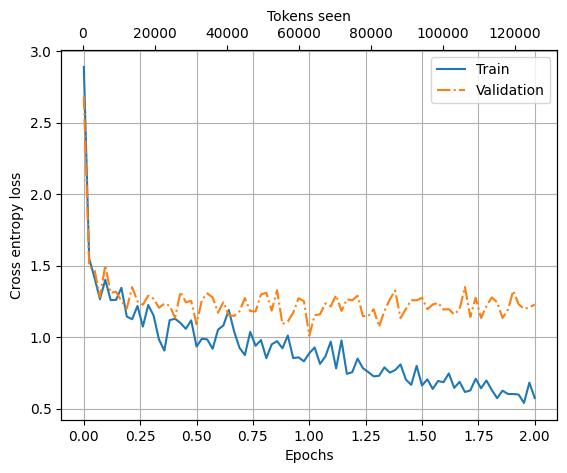

In [38]:
import matplotlib.pylab as plt


epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
# tokens_seen_tensor = torch.linspace(0, tokens_seen, len(train_losses))

fig, ax = plt.subplots()

ax.plot(
    epochs_tensor,
    train_losses,
    label='Train'
)

ax.plot(
    epochs_tensor,
    val_losses,
    '-.',
    label='Validation'
)

ax2 = ax.twiny()
ax2.plot(
    tokens_seen,
    train_losses,
    alpha=0
)

ax.grid()
ax.set_ylabel('Cross entropy loss')
ax.set_xlabel('Epochs')
ax2.set_xlabel('Tokens seen')
ax.legend()

In [45]:
for p in model.parameters():
    print(p.dtype)
    break

torch.float32


In [6]:
def get_response_for_entry(entry):
    input_text, target_text = format_instruction(entry)
    token_ids = generate(
        model=model,
        idx=text_to_tokens(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=GPT_CONFIG_355_openai["block_size"],
        eos_id=50256
    )
    generated_text = tokens_to_text(token_ids, tokenizer)

    response_text = generated_text[len(input_text):]
    #     .replace("### Response:", "")
    #     .strip()
    # )

    return response_text, target_text


for entry in data_train[:3]:
    print(input_text)
    response_text, target_text = get_response_for_entry(entry)
    print(f"\nCorrect response:\n>> {target_text}")
    print(f"\nModel response:\n>> {response_text}")
    print("-------------------------------------")
    break

NameError: name 'data_train' is not defined

In [3]:
from llama_index.llms.ollama import Ollama
from llama_index.core.evaluation import CorrectnessEvaluator


correctness_llm = Ollama('qwen3:8b')

evaluator = CorrectnessEvaluator(llm=correctness_llm)

In [5]:
evaluator.evaluate?

Signature:
evaluator.evaluate(
    query: Optional[str] = None,
    response: Optional[str] = None,
    contexts: Optional[Sequence[str]] = None,
    **kwargs: Any,
) -> llama_index.core.evaluation.base.EvaluationResult
Docstring:
Run evaluation with query string, retrieved contexts,
and generated response string.

Subclasses can override this method to provide custom evaluation logic and
take in additional arguments.
File:      ~/code/sturnus/.venv/lib/python3.13/site-packages/llama_index/core/evaluation/base.py
Type:      method